# Day 17 - Analisa  Teks: Genre & Deskripsi Netflix

**sangat banyak databerbentuk teks**: judul film, ulasan produk, komentar, deskripsi. Di notebook ini kita belajar dasar **analisis teks (text mining)** memakai katalog Netflix — tanpa library NLP eksternal,
cukup `pandas`, modul `collections`, dan `matplotlib`.

> 🎯 **Tujuan Pembelajaran**
> - Memahami konsep **tokenisasi** (memecah teks jadi kata) secara sederhana.
> - Mengenal **stopwords** (kata umum yang dibuang) dan kenapa perlu.
> - Menghitung **frekuensi kata** dengan `collections.Counter`.
> - Menganalisis genre populer dari kolom `listed_in`.
> - Mengukur panjang judul & deskripsi serta memvisualkannya.

## 📊 Tentang Dataset

Kita memakai **Netflix Movies and TV Shows**, daftar katalog judul yang tersedia di Netflix.

- **Sumber:** [Kaggle — shivamb/netflix-shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)
- **Ukuran:** ~8.800 baris × 12 kolom

| Kolom | Arti |
|-------|------|
| `type` | Movie atau TV Show |
| `title` | Judul |
| `listed_in` | Genre/kategori (dipisah koma) |
| `description` | Sinopsis singkat |
| `release_year` | Tahun rilis |
| `rating` | Rating usia (TV-MA, PG-13, dst.) |

## 1.Import Library

- **pandas** → mengolah tabel data.
- **matplotlib** → membuat grafik batang.
- **collections.Counter** → menghitung frekuensi kata dengan cepat.
- **re** → membersihkan teks (menghapus tanda baca).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

## 2.Import Dataset

In [2]:
!pip install -q kaggle
!kaggle datasets download -d shivamb/netflix-shows

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
netflix-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
!unzip -qq netflix-shows.zip

replace netflix_titles.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


## 3.Eksplorasi Awal Dataset

In [4]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Interpretasi:**
  - Setiap baris adalah satu judul. Kolom `listed_in` berisi beberapa genre
dipisah koma, dan
  - `description` berisi sinopsis berbentuk kalimat — keduanya target analisis teks kita.

In [5]:
print("bentuk data:", df.shape)

df[["type", "title", "listed_in", "description"]].info()

bentuk data: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   type         8807 non-null   object
 1   title        8807 non-null   object
 2   listed_in    8807 non-null   object
 3   description  8807 non-null   object
dtypes: object(4)
memory usage: 275.3+ KB


**Interpretasi:**
  - Kolom `description` dan `listed_in` bertipe `object` (teks). Mungkin ada
beberapa nilai kosong yang harus kita tangani sebelum mengolah teks.

In [6]:
#Cek missing value pada kolom yang akan di oleah


df[["title", "listed_in", "description"]].isnull().sum()

,0
title,0
listed_in,0
description,0


**Interpretasi:**
  - Bila ada nilai kosong di kolom teks, operasi string bisa error. Kita akan
membuang baris tanpa `description`/`listed_in` di tahap pembersihan.

## 4.Pembersihan Data

  - Untuk analisis teks, kita hanya butuh baris yang punya `description` dan `listed_in`. Kita juga buang duplikat judul bila ada.

In [7]:
df = df.dropna(subset=['listed_in', 'description']).copy()
df = df.drop_duplicates(subset=['title', 'type'])
print("bentuk data:", df.shape)

bentuk data: (8807, 12)


## 5.Eda dan Visualisasi

### a) Proporsi Movie vs TV Show

sebelum masuk ke teks, kita lihat komposisi katalogm

In [8]:
tipe = df["type"].value_counts()
tipe

,count
type,
Movie,6131
TV Show,2676


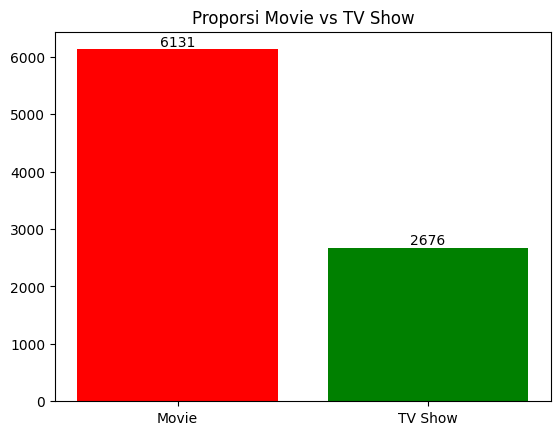

In [9]:
plt.bar(tipe.index,
        tipe.values,
        color=["red","green"])
plt.title("Proporsi Movie vs TV Show")
for i, v in enumerate(tipe.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

Interpretasi:
- Katalog netflix di dominasi oleh movie dibanding TV show

### b) Genre paling populer (listed_in)

Kolom `listed_in` berisi beberapa genre dipisah koma, mis. `"International TV Shows, TV Dramas"`.

Kita pecah (split) per koma, rapikan spasi, lalu hitung dengan `Counter`.

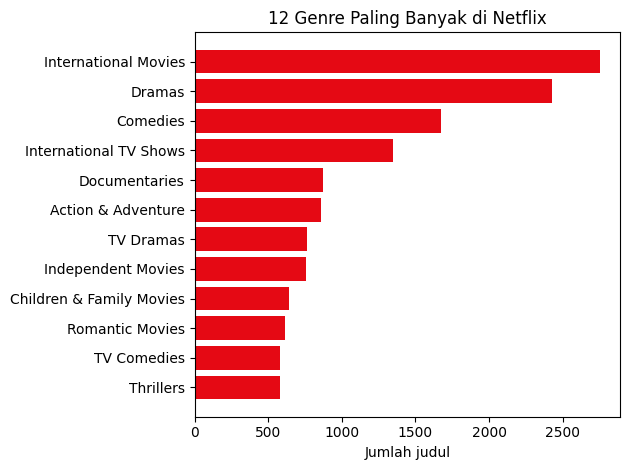

In [12]:
genre_counter = Counter()
for baris in df["listed_in"]:
    for g in baris.split(","):
        genre_counter[g.strip()] += 1

top_genre = genre_counter.most_common(12)
labels = [g for g, _ in top_genre][::-1]
values = [n for _, n in top_genre][::-1]

plt.barh(labels, values, color="#E50914")
plt.title("12 Genre Paling Banyak di Netflix")
plt.xlabel("Jumlah judul")
plt.tight_layout()
plt.show()

Interpretasi:
  - Genre Internasional Movie, Dramas, adn Komedi mendominasi Katalog Netflix
  - Ini memberikan gambaran fokus konten Netflix yang sangat global dan berorientasi drama / komedi

### c) Frekuesi kata pada deskripsi ( tokenisasi + stopword ) manual

Sekarang inti analisis teks. Langkahnya:
1. Gabungkan semua `description` menjadi satu teks besar.
2. **Tokenisasi**: ubah ke huruf kecil dan ambil hanya kata (buang tanda baca) dengan regex.
3. Buang **stopwords** — kata umum (the, a, of, ...) yang tidak informatif.
4. Hitung kata tersisa dengan `Counter`.

In [13]:
# Stopwords manual — set MINIMAL untuk pembelajaran (bukan daftar lengkap).
# Untuk proyek nyata, pakai daftar dari NLTK/spaCy atau perluas sendiri.
# (Karena ini sebuah set, duplikat otomatis diabaikan — di sini sudah dirapikan.)
STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "for", "with",
    "is", "are", "was", "were", "be", "by", "as", "at", "from", "that",
    "this", "it", "its", "his", "her", "their", "they", "he", "she", "him",
    "who", "but", "into", "out", "up", "off", "than", "then", "when", "while",
    "after", "before", "about", "over", "new", "two", "one", "all", "more",
    "you", "your", "has", "have", "had", "will", "must", "can",
    "them", "not", "no", "so", "if", "what", "which", "s",
}

In [15]:
teks = " ".join(df["description"].astype(str)).lower()
word = re.findall(r"\b[a-z]+\b", teks)
word = [w for w in word if w not in STOPWORDS and len(w) > 2]
word_counter = Counter(word)

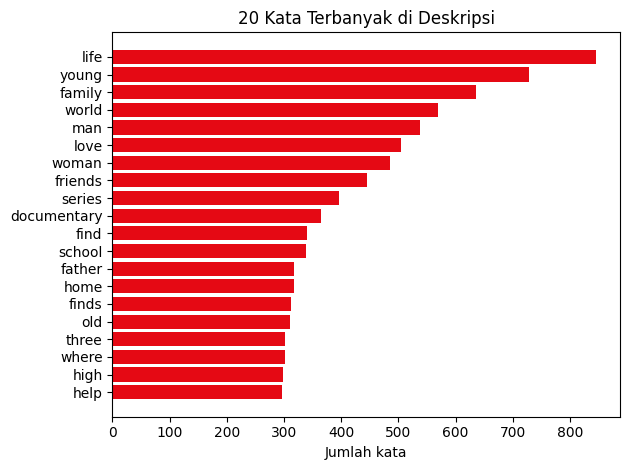

In [16]:
top_word = word_counter.most_common(20)
labels = [w for w, _ in top_word][::-1]
values = [n for _, n in top_word][::-1]

plt.barh(labels, values, color="#E50914")
plt.title("20 Kata Terbanyak di Deskripsi")
plt.xlabel("Jumlah kata")
plt.tight_layout()
plt.show()

**Interpretasi:**
- Kata seperti *life*, *family*, *young*, *love*, *world* sering muncul.
- Ini menunjukkan tema cerita yang dominan di Netflix berkisar pada **kehidupan, keluarga, dan percintaan**
- tema universal yang relatable bagi penonton global.

### d) panjang judul dan deskripsi

ukur jumlah karakter judul dan jumlah kata deskripsi, lalu lihat sebarannya menggunakan histogram

In [17]:
df["long_title"] = df["title"].astype(str).str.len()
df["long_description"] = df["description"].astype(str).str.split().str.len()

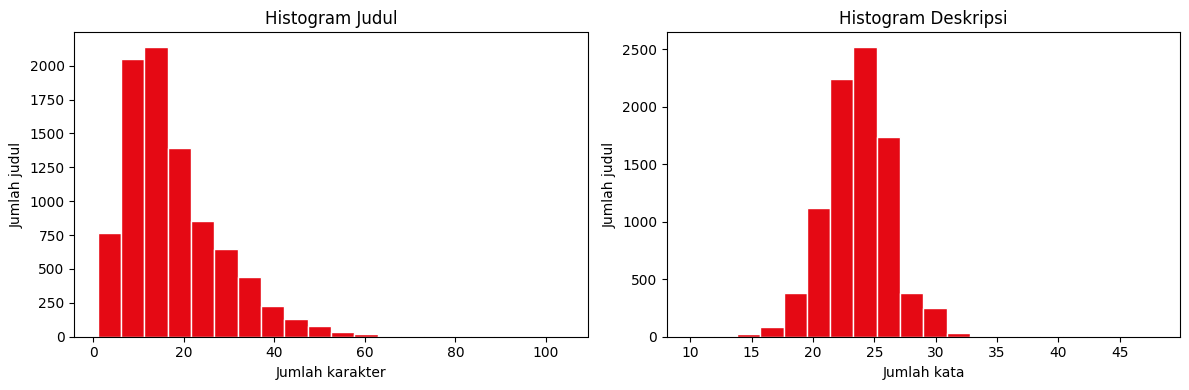

In [21]:
fig, ax= plt.subplots(1, 2, figsize=(12, 4))


ax[0].hist(df["long_title"], bins=20, color="#E50914", edgecolor="white")
ax[0].set_title("Histogram Judul")
ax[0].set_xlabel("Jumlah karakter")
ax[0].set_ylabel("Jumlah judul")

ax[1].hist(df["long_description"], bins=20, color="#E50914", edgecolor="white")
ax[1].set_title("Histogram Deskripsi")
ax[1].set_xlabel("Jumlah kata")
ax[1].set_ylabel("Jumlah judul")

plt.tight_layout()
plt.show()




**Interpretasi:**
- Mayoritas judul cukup pendek (di bawah ~30 karakter)
-  sedangkan deskripsi terkonsentrasi sekitar 20–25 kata.
- Konsistensi ini wajar karena sinopsis Netflix mengikuti format
ringkas yang seragam.

In [25]:
# Ringkasan statistik panjang teks

df[["long_title", "long_description"]].describe().round(1)

,long_title,long_description
count,8807.0,8807.0
mean,17.7,23.9
std,10.6,2.8
min,1.0,10.0
25%,10.0,22.0
50%,15.0,24.0
75%,23.0,26.0
max,104.0,48.0


**Interpretasi:**
  - Rata-rata deskripsi sekitar 23–24 kata — padat dan to the point, dirancang agar penonton cepat memutuskan apakah tertarik menonton.

## 6.Insight dan Kesimpulan

  - Katalog Netflix didominasi **Movie**, dengan genre teratas *International Movies*, *Dramas*, dan *Comedies*.
  - Analisis frekuensi kata deskripsi menunjukkan tema dominan: **life, family, love, world** — tema universal.
  - Judul cenderung **pendek**, deskripsi **ringkas** (~23 kata) dengan format yang konsisten.
  - Kita membuktikan bahwa analisis teks dasar (tokenisasi + stopwords + `Counter`) bisa dilakukan  hanya dengan pustaka standar Python, tanpa library NLP berat.



Teknik tokenisasi & penghitungan frekuensi ini adalah fondasi sebelum masuk ke NLP lanjutan seperti TF-IDF

## 💡 Insight & Jebakan Data

Analisis teks sederhana (frekuensi kata) sudah cukup mengungkap **tema dominan** katalog — modal awal sebelum teknik lanjutan seperti TF-IDF (lihat NB48).

### ⚠️ Jebakan Data

  - Hasil analisis teks **sangat bergantung pada pilihan stopwords & cara tokenisasi**. Daftar stopwords di sini sengaja **minimal** — kata umum yang tersisa bisa mendominasi peringkat.

  - `Counter` menghitung kata mentah; kata berfrekuensi tinggi belum tentu **bermakna**. Selalu pertimbangkan menyaring lebih lanjut atau memberi bobot (mis. TF-IDF).